# 1. Import necessary libraries

In [138]:
#import libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sqlite3

# import database/data

In [139]:
conn = sqlite3.connect(r'C:/Users/SRIRAM/Downloads/Churn_Analysis/customer_churn.db')

sql_query = """ SELECT name from sqlite_master WHERE type='table' """

tables = pd.read_sql(sql_query,conn)

#create dataframe for each table

for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")


conn.close()



Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


# Print table names and column names

In [140]:
conn = sqlite3.connect(r'C:/Users/SRIRAM/Downloads/Churn_Analysis/customer_churn.db') 

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});" #PRAGMA is a command within sqlite3 which is helpful in fetching the info of the table/schema.
    columns = pd.read_sql(columns_query, conn)  #read the fetched data with the help of pandas library
    print("Columns:")
    print(columns['name'].tolist())

# Close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


# 2. Data cleaning

In [141]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [142]:
df_db_customer.tail() #Also, look for tail() for better understanding like a safe practice

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [143]:
df_db_customer.info() #Here, we can find out the undesirable values and null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [144]:
# i. Rename column - name
# ii. Drop columns - interests and pincode
# iii. Change datatype of column - dob
# iv. Data standardization - Gender
# v. Fix missing values - Country

# i. Rename column - name

In [145]:
df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace = True) #inplace = True does the update of the change made at this stage
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


# ii. Drop columns - interests and pincode

In [146]:
# df_db_customer.drop(df_db_customer.columns[-2:], axis = 1)


# df_db_customer.columns[6:] -- This also does the same
# df_db_customer.drop(df_db_customer.columns[6:], axis = 1)

df_db_customer.drop(columns=['interests','pincode'], inplace = True)  #-- This is another way

In [147]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     21 non-null     object
 1   customer_name  21 non-null     object
 2   country        18 non-null     object
 3   state          21 non-null     object
 4   gender         21 non-null     object
 5   dob            21 non-null     object
dtypes: object(6)
memory usage: 1.1+ KB


# iii. Change datatype of column - dob

In [148]:
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [149]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     object        
 1   customer_name  21 non-null     object        
 2   country        18 non-null     object        
 3   state          21 non-null     object        
 4   gender         21 non-null     object        
 5   dob            21 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.1+ KB


# iv. Data standardization - Gender

In [150]:
df_db_customer['gender'].unique()

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [ ]:
# We want only two values, Male and Female. So, change Men to Male and Women to Female

In [151]:
df_db_customer['gender'] = df_db_customer['gender'].replace({'Women' : 'Female',
                                  'Men' : 'Male'})

In [152]:
#Check again
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

# v. Fix missing values - Country

In [153]:
df_db_customer['country'].isna() #Where the output is True, there the value is NULL

0     False
1     False
2     False
3     False
4     False
5      True
6     False
7     False
8      True
9     False
10    False
11    False
12     True
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
Name: country, dtype: bool

In [154]:
# To check the rows where the outcome is True in the above output

df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [155]:
# To fill the above NULL's we have one way which is manual way like put condition like where state='Delhi' there country='India' etc...
# Another way is to use .fillna('value')

df_db_customer['country'].fillna('America')

0       India
1       India
2       India
3       India
4       India
5     America
6       India
7       India
8     America
9       Nepal
10      India
11      India
12    America
13      India
14      India
15      India
16      India
17      India
18      India
19      India
20      India
Name: country, dtype: object

In [156]:
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,None,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,None,Kathmandu
9,Nepal,Kathmandu


In [157]:
#This is another way, we write one own logic to fill the null rows, this logic may not be valid all the time, it changes acc to the data

# country and state - unique value pair

# Creating state → country map from non-null rows
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

# Fill the missing country using State
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [158]:
# No output should come for this line of code
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [159]:
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [160]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [161]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


# Fix the data columns - datatype -> object to datetime

In [162]:
#Converting the datatype of multiple columns at a time unlike the above procedure where the change was made for only one column

date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [163]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [164]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [165]:
# Here we can delete the last two undesirable columns which are of no use for now

df_db_support.drop(columns=['col_1','comment'], inplace = True)

In [166]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
dtypes: int64(1), object(3)
memory usage: 420.0+ bytes


In [167]:
# Change the datatype of the column complaint_date to datetime from object

df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [168]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


# 3. Feature Engineering and Data Analysis

In [169]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [170]:
# In the above rows, we can observe that the is cancellation_date for some customers that means the churn of the customer is done which means the 
# customer stopped using/buying the product. We can see that there is churn_score but there is no Churn_Flag . So, we create a churn flag, which means
# wherever there is cancellation date there the Churn_Flag will be Yes, rest the Churn_Flag is No.


df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)

In [171]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [172]:
# Here now, we want to analyze the complete data at one place. So, for that we will JOIN/MERGE the tables for better understanding, visibility
# readability etc. Here, based on the df_db_subscription we have to merge the other two tables

df = (df_db_subscription
    .merge(df_db_customer, on='customerid', how='left')
    .merge(df_db_support, on='customerid', how='left')   )

In [173]:
df_db_subscription.shape   #Here, we have only 21 rows, which is the left table 

(21, 12)

In [174]:
df.shape    #But, here we got 23 rows, 2 extra rows which means something has gone wrong

(23, 20)

In [175]:
df_db_subscription['customerid'].nunique() #OK

21

In [176]:
df_db_customer['customerid'].nunique()    #OK

21

In [177]:
df_db_support['customerid'].nunique()   #OK

7

In [178]:
df_db_support['customerid'].size    #Not OK

9

In [179]:
# So, in the table df_db_support the no.of unique values are 7 but the no.of data rows are 9 because of which we are getting 23 rows when merged
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [180]:
# So, here we can see two rows extra for two customers 0003-MKNFE, 0022-TCJCI
# Here, we can remove one row for each because it is causing ambiguity when merged. So, we decide to keep the latest record based on the date

df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [181]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [182]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep= 'last')
#This line will retain the latest value and deletes the old

In [183]:
df_db_support['customerid'].size  # Now, OK

7

In [184]:
# Merge df

df = (df_db_subscription
    .merge(df_db_customer, on='customerid', how='left')
    .merge(df_db_support, on='customerid', how='left')   )

In [185]:
df.shape

(21, 21)

In [187]:
df.to_csv('exported_churn_data.csv', index=False) # The exported file is saved in C:\Users

# Data Analysis

In [ ]:
# 1. Churn Rate

In [188]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [195]:
churn_rate = df['churn_flag'].mean() * 100    #This means around 28% of our users are in churn

In [196]:
print("Churn Rate = ", round(churn_rate,2), "%")

Churn Rate =  28.57 %


In [197]:
# 2. Find the Retention Rate as well, which is opposite to Churn Rate

retention_rate = 100 - churn_rate
print("Retention_rate = ", round(retention_rate,2), "%")

Retention_rate =  71.43 %


In [199]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0


In [204]:
# 3. Churn by Plan type
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [ ]:
# From above we can observe that 60% of basic plan users are in Churn, only 14% of Premium plan users are in Churn and
# only 22% of Std users are in Churn. Good news will be Premium Users are safe, but most of the Basic plan users are in Churn which is not good.

In [205]:
# 4a. Churn by State

churn_by_state = (df.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_state)

           state  churn_rate_pct
0          Delhi           25.00
1      Karnataka          100.00
2      Kathmandu            0.00
3    Maharashtra            0.00
4      Meghalaya           66.67
5       Nagaland            0.00
6      Rajasthan            0.00
7      Telangana           50.00
8  Uttar Pradesh            0.00


In [206]:
# 4b. Churn by Subscription type

churn_by_stype = (df.groupby('subscription_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_stype)

  subscription_type  churn_rate_pct
0           Organic            0.00
1              Paid           16.67
2          Refferal           83.33


In [ ]:
# 4c. Churn by State + sum(revenue) & count of users
# 4d. Churn by Subscription Type + sum(revenue) & count of users

In [ ]:
# 5. ARPU - Average Revenue Per User

In [207]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [209]:
arpu = df['monthly_charges'].mean()
print("ARPU = ", round(arpu,2))

ARPU =  18.85


In [215]:
# 6. Average Customer Tenure  -- no.of days the user has used our service either till cancellation date or till date from subscription_start_date

today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(), (df['cancellation_date'] - df['subscription_start_date']).dt.days, (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (days) =", round(avg_tenure,0))

Avg Tenure (days) = 1492.0


In [224]:
# 6b. Find age of customer till date
today = pd.Timestamp.today()

df['age'] = np.where(
    df['dob'].notna(),
    today.year - df['dob'].dt.year -
    (
        (today.month < df['dob'].dt.month) |
        ((today.month == df['dob'].dt.month) & (today.day < df['dob'].dt.day))
    ),
    0
).astype(int)

print(df[['customer_name', 'age']])

   customer_name  age
0         keshav   44
1         raghav   30
2         lalita   48
3          mohan   24
4           mira   36
5          durga   37
6           mina   49
7          madan   27
8           maya   41
9          arjun   32
10         shiva   29
11     rangadevi   45
12        chitra   21
13          raju   34
14        Madhav   46
15       parvati   40
16         rikim   31
17      vishakha   25
18    raghvendra   42
19       rishabh   35
20        sudevi   48


In [227]:
# 7. Revenue at risk - revenue lost from churned users

revenue_at_risk = df.loc[df['churn_flag'] == 1, 'monthly_charges'].sum()
print("Revenue at Risk: ", revenue_at_risk, "lakh")

Revenue at Risk:  73.94 lakh


In [228]:
# 8. Escalation Rate
df['escalations'].unique()

array([nan, 'Y', 'N'], dtype=object)

In [233]:
escalation_rate = (df['escalations'] == 'Y').mean() * 100
print("Escalation Rate =", round(escalation_rate,2),"%" )

Escalation Rate = 19.05 %


In [238]:
# 9. Average Complaint Rate per User
avg_complaints = df['complaint_count'].sum()/df['customerid'].nunique()
print("Average Complaints Per User: ", round(avg_complaints,2))    #the output approx explains that 1 in 4 complaints which is low

Average Complaints Per User:  0.43


In [247]:
# 10. Correlation - Escalation vs Churn

#df['escalations'] = np.where(df['escalations']=='Y',1,0)  # Encoding str to int type
corr_df = df[['escalations','churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])

print("Correlation between Escalation and Churn is: ", round(correlation,2))


Correlation between Escalation and Churn is:  0.77


In [254]:
# 11. Churn Risk based on churn score of the user -- create a column using existing column - Churn_Risk

conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]
choices = ['low', 'medium', 'high']

df['churn_risk'] = np.select(conditions, choices, default = 'unknown')

df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,age_in_days,age,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,Male,1982-04-12,NaT,0,NaN,NaN,1943.0,16160,44,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,11187,30,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,Female,1978-02-15,NaT,0,NaN,NaN,1328.0,17677,48,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,Male,2001-08-30,NaT,0,NaN,NaN,2618.0,9080,24,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,13215,36,high
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,...,Female,1988-12-10,2025-03-18,0,90.0,1.0,1483.0,13726,37,low
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,Female,1976-09-21,2024-11-01,0,30.0,1.0,1142.0,18189,49,high
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,...,Male,1999-03-14,NaT,0,NaN,NaN,2338.0,9980,27,low
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,...,Female,1985-07-07,NaT,0,NaN,NaN,1084.0,14978,41,low
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,None,6.99,335,...,Male,1993-10-29,NaT,0,NaN,NaN,1559.0,11942,32,low


In [252]:
df[['churn_risk', 'churn_score']].head()

,churn_risk,churn_score
0,low,12
1,high,91
2,low,34
3,low,8
4,high,88


In [253]:
df[['churn_risk', 'churn_score']].tail()

,churn_risk,churn_score
16,medium,62
17,low,27
18,high,99
19,low,7
20,low,47


# 4. Data Visualization using Matplotlib

In [ ]:
# Seaborn is developed upon the matplotlib library only. 

In [255]:
df_visual = df.copy()

In [256]:
df_visual.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,age_in_days,age,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,Male,1982-04-12,NaT,0,NaN,NaN,1943.0,16160,44,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,11187,30,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,Female,1978-02-15,NaT,0,NaN,NaN,1328.0,17677,48,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,Male,2001-08-30,NaT,0,NaN,NaN,2618.0,9080,24,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,13215,36,high


In [258]:
df_visual.shape

(21, 25)

In [259]:
df.shape

(21, 25)

In [260]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'age_in_days', 'age', 'churn_risk'],
      dtype='object')

In [261]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'age_in_days', 'age', 'churn_risk'],
      dtype='object')

In [ ]:
# So, basically we created a clone for the 'df' so that the copy of 'df' is stored in 'df_visual' using '.copy()' function

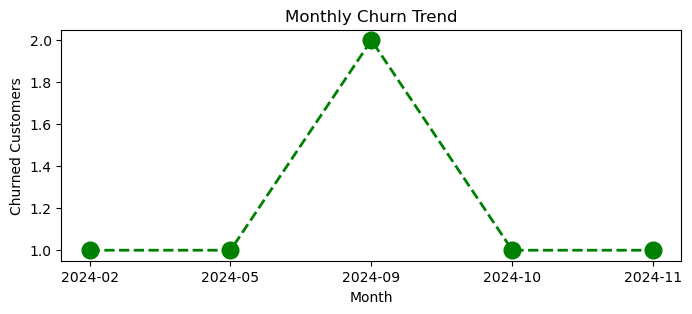

In [271]:
# 4.1 Monthly Churn Trend (Any trend chart is based on time series like date/month/year etc, This is a time-series KPI)

#df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

#df_visual[df_visual['churn_flag'] == 1]

churn_trend = df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))

plt.plot(churn_trend.index.astype('str'), churn_trend.values, color='green', marker='o', linestyle='dashed',linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

In [273]:
# 4.2 Churn By Plan Type

df_visual.head()

#Here, we have Basic, Premium and Standard. For this we can use barchart, piechart etc

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,age_in_days,age,churn_risk,cancellation_month
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,1982-04-12,NaT,0,NaN,NaN,1943.0,16160,44,low,NaT
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,11187,30,high,2024-09
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,1978-02-15,NaT,0,NaN,NaN,1328.0,17677,48,low,NaT
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,2001-08-30,NaT,0,NaN,NaN,2618.0,9080,24,low,NaT
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1990-05-05,2024-01-20,1,20.0,1.0,419.0,13215,36,high,2024-02


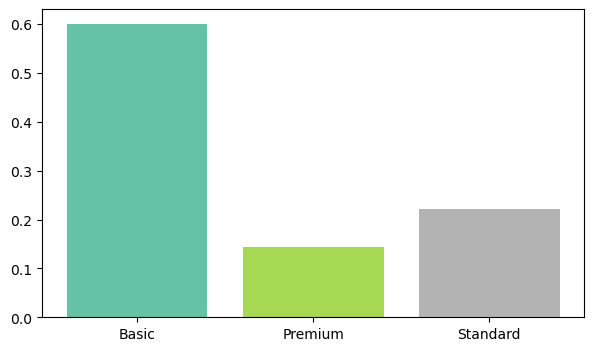

In [284]:
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

#colors = ['yellow','purple','cyan']
colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))  # This line give some randome color to the bars in the barchart

plt.figure(figsize=(7,4))

plt.bar(churn_plan.index, churn_plan.values, color=colors)

plt.show()

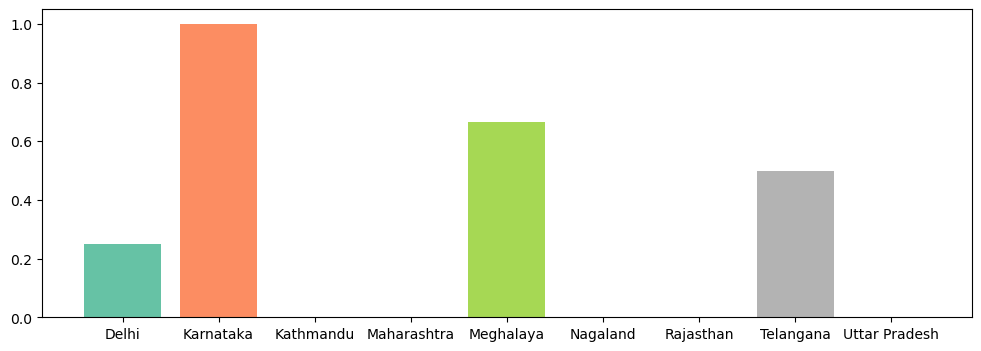

In [287]:
# 4.3 Churn By States

churn_plan = df_visual.groupby('state')['churn_flag'].mean()

#colors = ['yellow','purple','cyan']
colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))  # This line give some randome color to the bars in the barchart

plt.figure(figsize=(12,4))

plt.bar(churn_plan.index, churn_plan.values, color=colors)

plt.show()

# Visualization Using Seaborn

In [289]:
# Encoding -- convert str to numeric so that we can find correlation between features

df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'age_in_days', 'age', 'churn_risk',
       'cancellation_month'],
      dtype='object')

In [295]:
df_visual[['plan_type', 'contract_type','churn_score','churn_flag','churn_risk','escalations',]].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [296]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,1
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,1


In [297]:
import warnings
warnings.filterwarnings('ignore')

In [300]:
# incorrect method of encoding - as numbers are not assigned based on priority
df_encoded = df_visual[['plan_type', 'contract_type','churn_score','churn_flag','churn_risk','escalations',]]

categorical_cols = ['plan_type', 'contract_type','churn_risk']

for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

<Axes: >

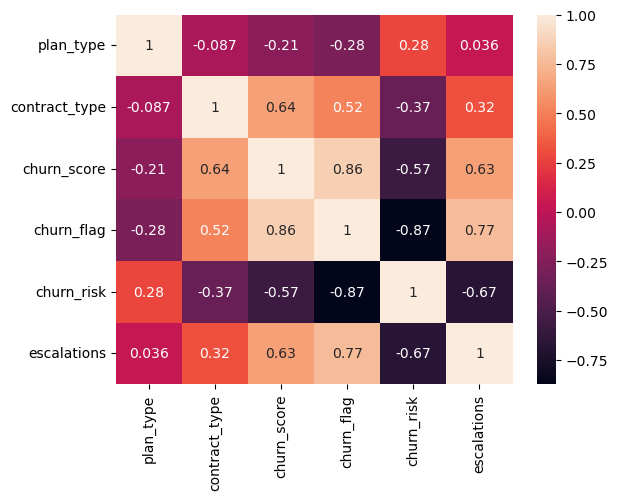

In [299]:
# Heatmap (correlation matrix) (fields must be numeric only)

sns.heatmap(df_encoded.corr(), annot = True)

In [301]:
# Correct method of encoding - based on priority
df_encoded = df_visual[['plan_type', 'contract_type','churn_score','churn_flag','churn_risk','escalations',]]

order_mappings = {'plan_type' : ['Basic','Standard','Premium'],
                  'contract_type' : ['Monthly', 'Annual'],
                  'churn_risk' : ['low', 'medium', 'high']
                 }

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered = True).codes

In [303]:
df_visual[['plan_type', 'contract_type','churn_score','churn_flag','churn_risk','escalations',]].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [302]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

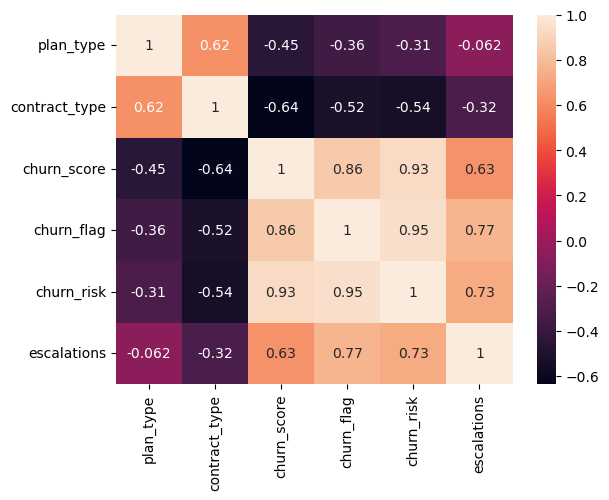

In [305]:
# Heatmap (correlation matrix) (fields must be numeric only)
sns.heatmap(df_encoded.corr(), annot = True)

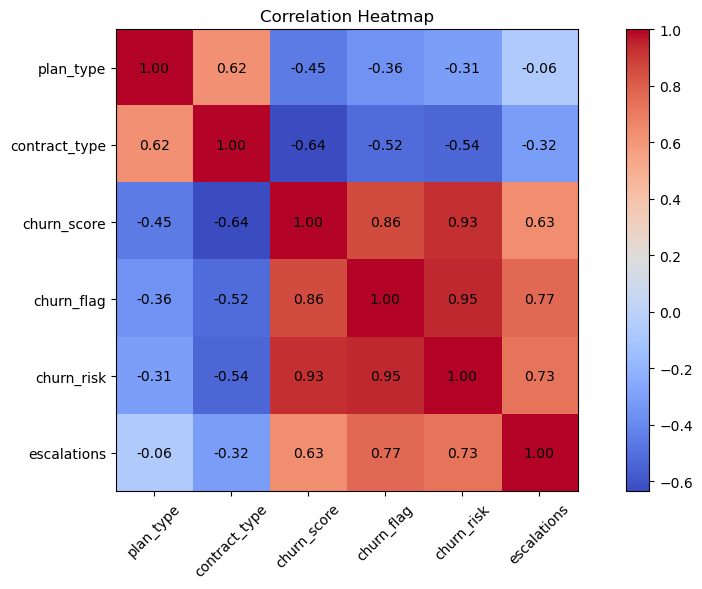

In [306]:
# Heatmap Using Matplotlib - difficult to plot it

corr_matrix = df_encoded.corr() # Correlation matrix

fig, ax = plt.subplots(figsize=(10, 6)) # Create figure

cax = ax.imshow(corr_matrix, cmap='coolwarm') # Heatmap

fig.colorbar(cax) # Add colorbar

# Axis labels
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))

ax.set_xticklabels(corr_matrix.columns, rotation=45)
ax.set_yticklabels(corr_matrix.columns)

# Annotate values inside cells
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha='center',
            va='center'
        )

plt.title('Correlation Heatmap') # Title

plt.tight_layout()
plt.show()

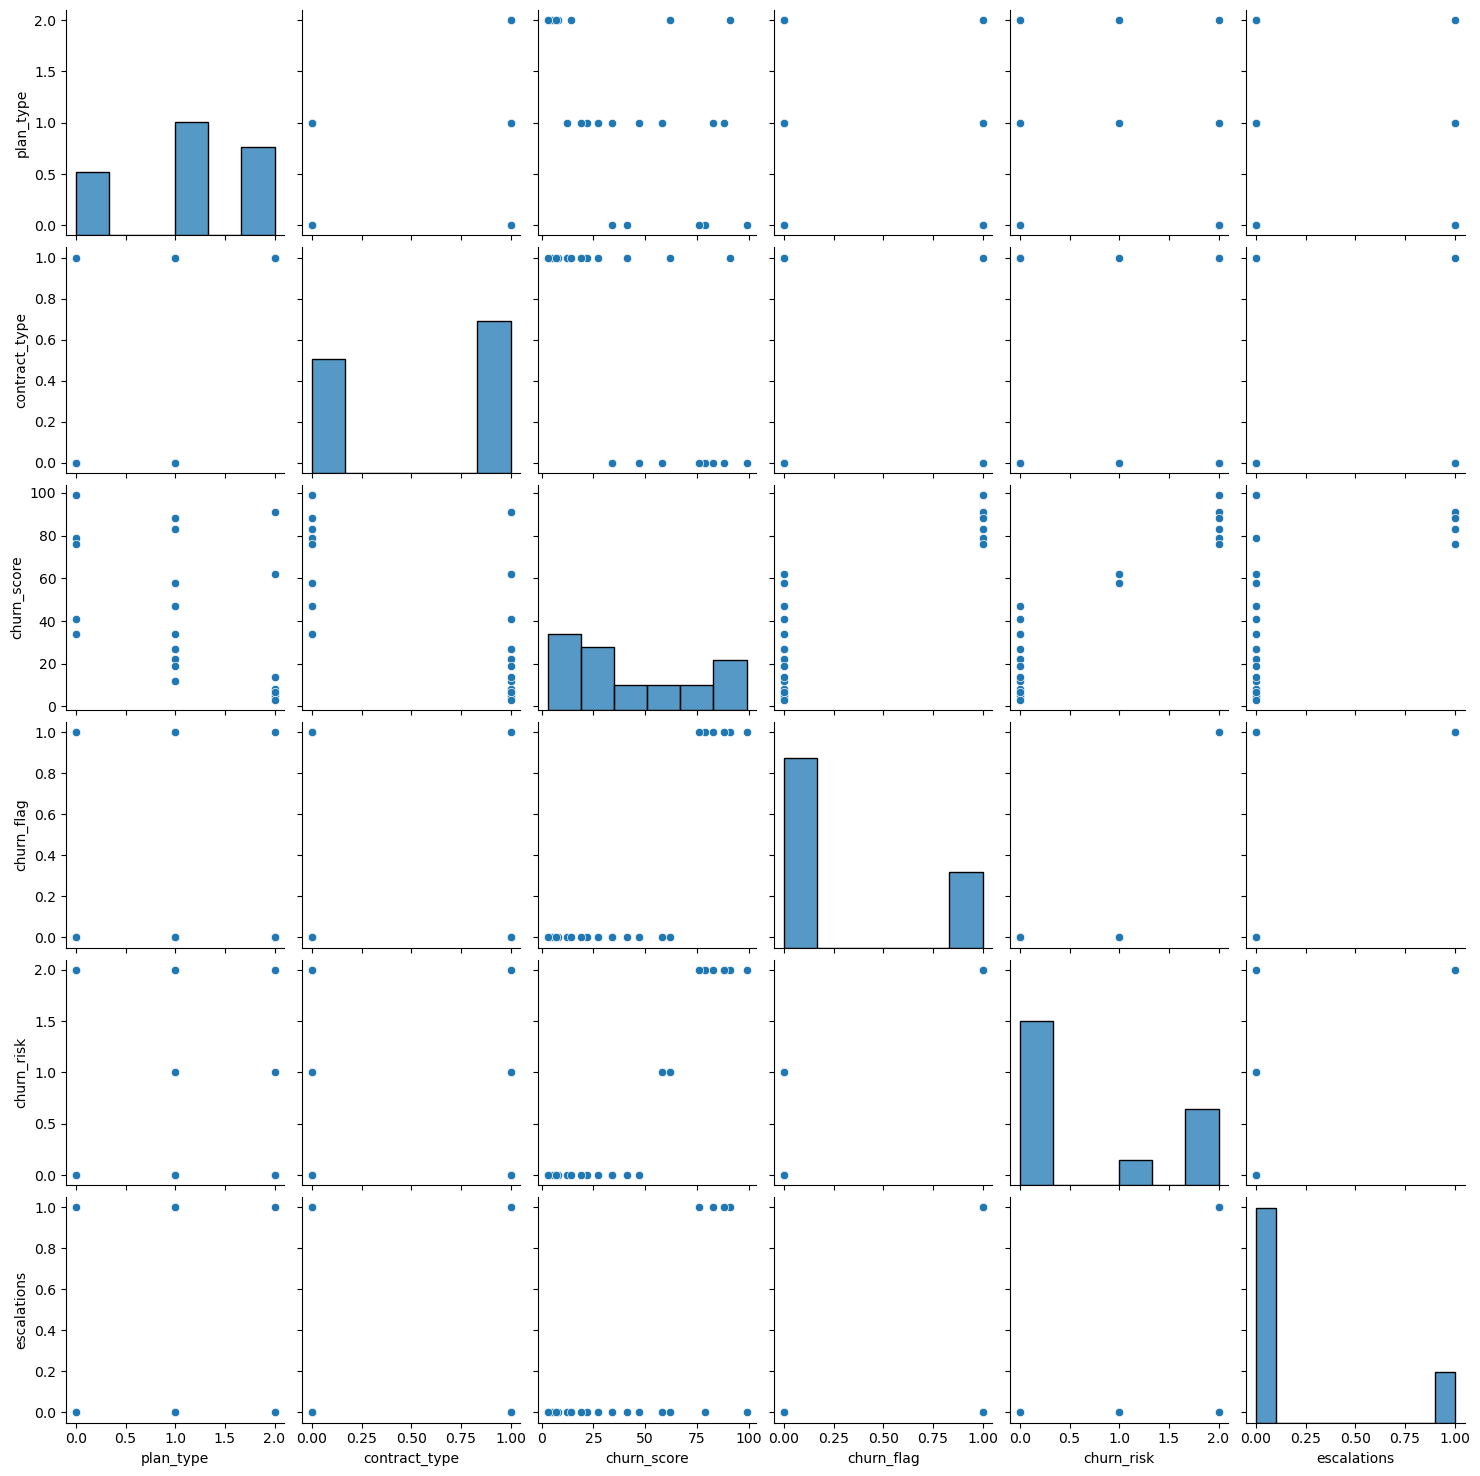

In [308]:
# Pair plot -- uses to find relationships in a dataset

sns.pairplot(df_encoded)

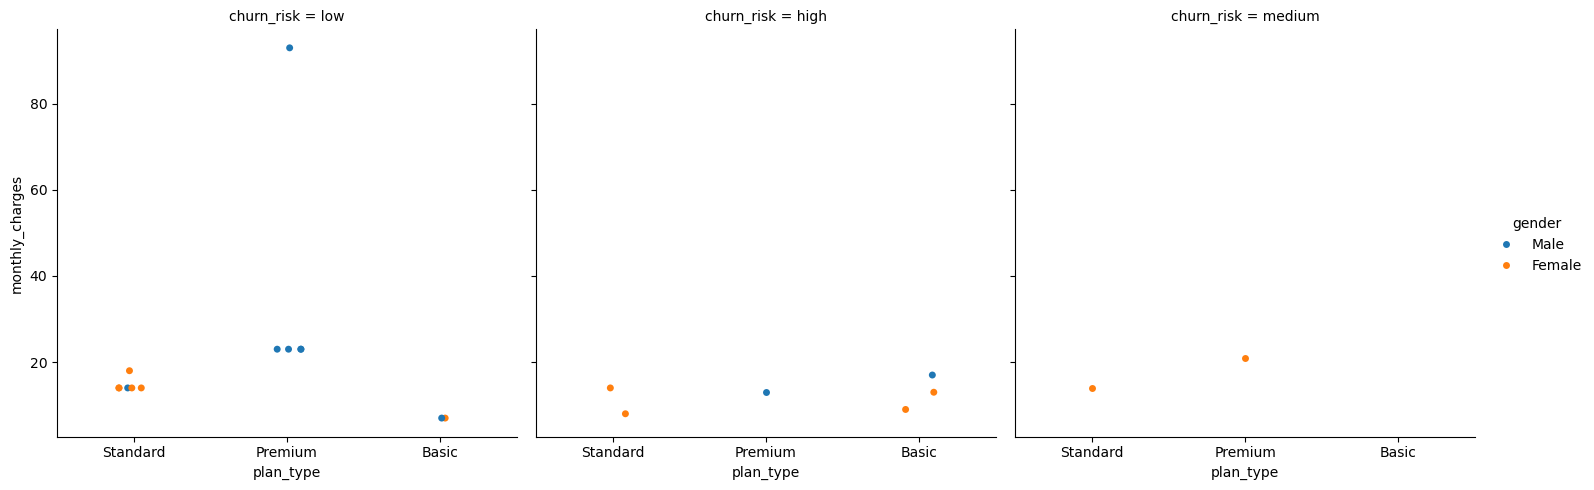

In [309]:
# Catplt/Facegrid plot -- We can plot multiple columns at a time/ Multi-dimension comparision

sns.catplot(data = df_visual,
            x = 'plan_type',
            y = 'monthly_charges',
            hue = 'gender',
            col = 'churn_risk',)

# 5. Pivot Table

In [316]:
pd.pivot_table(
    df_visual,
    values = 'churn_flag',
    index = 'plan_type',
    aggfunc = 'mean'
)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [317]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'age_in_days', 'age', 'churn_risk',
       'cancellation_month'],
      dtype='object')

In [319]:
pd.pivot_table(
    df_visual,
    index = 'plan_type',
    values = ['monthly_charges','customerid','churn_flag'],    
    aggfunc = {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
    }
).reset_index()

,plan_type,churn_flag,customerid,monthly_charges
0,Basic,0.600000,5,52.95
1,Premium,0.142857,7,218.93
2,Standard,0.222222,9,123.91


In [ ]:
# Working with SQL in Python(Pandas)

In [320]:
# Create db in sql

conn = sqlite3.connect('test_database.sqlite')

# Table details

conn.execute("CREATE TABLE users (first_name TEXT, country TEXT,budget INTEGER) ")

# commit and save

conn.commit()

In [321]:
# Insert data (Using cursor -- cursor helps in inserting the data in the specified table)

cursor = conn.cursor()

# Write sql query to insert records in sql table
cursor.execute(
    """
    INSERT INTO users VALUES 
                   ('Madhav', 'India', 5000),
                   ('Sriram', 'India', 7000),
                   ('Yash', 'Australia', 3500)
                
    """
)

# commit and save
conn.commit()

print("Data inserted successfully")

Data inserted successfully


In [322]:
# Check inserted data in table

conn = sqlite3.connect('test_database.sqlite')

query = """ SELECT * FROM users  """

df_results = pd.read_sql(query, conn)

df_results.head()


,first_name,country,budget
0,Madhav,India,5000
1,Sriram,India,7000
2,Yash,Australia,3500


In [323]:
# Aggregation 

query = """ SELECT country, SUM(budget) as Cumulative_Budget FROM users GROUP BY country  """

df_agg = pd.read_sql(query, conn)

df_agg

,country,Cumulative_Budget
0,Australia,3500
1,India,12000


In [324]:
conn.close()    #best practice to close the conn with db once the task is complete